In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data, compute_true_z
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler

device = torch.device("cpu")

In [2]:

if __name__ == '__main__':
    
    bench_repeat_loss_list = []
    regression_loss_total_list = []
    model_loss_total_list = []
    regression_loss_predindex_list = []
    model_loss_predindex_list = []
    bench1_loss_list = []
    bench2_loss_list = []
    bench2loss_predindex_list = []
    bench_repeat_loss_predindex_list = []
    benchloss_predindex_list = []
    models = []
    


    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 12             # number of heads
    ncum = 2                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 100
    target_sample_size = 8
    nrepp = 10
    seeds = [42]
    
    
    for iteration in range(len(seeds)):
        
        # Set the random seed for reproducibility
        seed = seeds[iteration]
        torch.manual_seed(seed)

        if data_str == "simulation":
            n = 500 
            p = 10
            maxlen = 10
            # Create Dataset and DataLoader
            train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
            eval_dataset = SimulatedDataset(1000, p, maxlen=maxlen, device = device).data
            predindex = 2
            
        else:
            # load real data
            data, maxlen = load_real_data(data_str)
            
            n = int(0.8*len(data))
            p = data[0].shape[1]
            print("Sample size: ", len(data))
            
            train_dataset = data[:n]
            eval_dataset = data[n:]
            predindex = 9

        

        mask_pairwise = create_custom_mask_pair(maxlen, device)
        distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
        pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)

    
        dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
        
        eval_dataloader = DataLoader(eval_dataset, batch_size=1000, shuffle=False, collate_fn=collate_function, num_workers=0)
       
    
        models.append(MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise, pairwise_distance_matrix, distance_to_end_matrix,  device))




        print("distance to end par:", models[iteration].multiheadattn.distance_to_end_weight.item(), "\n")
        print("distance between pair par:", models[iteration].multiheadattn.distance_between_two_positions_weight.item(), "\n")


        # models[iteration].apply(init_weights_recursive)
        models[iteration].to(device)

        # model = torch.compile(model)
        # Start the timer
        start_time = time.time()

        # Define optimizer
        # optimizer = optim.Adam(models[iteration].parameters(), lr= learning_rate, weight_decay=lambda_l2)
        optimizer = optim.Adam(models[iteration].parameters(), lr= learning_rate)
        
        print("Number of Parameters", transformerFunctions.count_parameters(models[iteration]))
        
        run_path = transformerFunctions.train_mini_transformer(models[iteration], dataloader, eval_dataloader, optimizer, lambda_l2, EPOCHS, device)


        # End the timer
        end_time = time.time()

        # Calculate and print the execution time
        execution_time = end_time - start_time 
        print(f"Execution time: {execution_time:.6f} seconds")
        
        # Evaluate the model
        
        eval_dataloader = DataLoader(eval_dataset, batch_size=1, shuffle=False, collate_fn=collate_function, num_workers=0)
       

    

distance to end par: -0.07934059947729111 

distance between pair par: -0.022634029388427734 

Number of Parameters 452
EPOCH 1:
avg_loss:     17.63918 penalty    : 0.01688
avg_loss_val: 10.48912 penalty_val: 0.01687
EPOCH 11:
avg_loss:     8.09603 penalty    : 0.02292
avg_loss_val: 8.54559 penalty_val: 0.02293
EPOCH 21:
avg_loss:     7.95139 penalty    : 0.03452
avg_loss_val: 8.35621 penalty_val: 0.03452
EPOCH 31:
avg_loss:     7.88531 penalty    : 0.04413
avg_loss_val: 8.30785 penalty_val: 0.04413
EPOCH 41:
avg_loss:     7.86070 penalty    : 0.04907
avg_loss_val: 8.25389 penalty_val: 0.04907
EPOCH 51:
avg_loss:     7.83082 penalty    : 0.05314
avg_loss_val: 8.21814 penalty_val: 0.05313
EPOCH 61:
avg_loss:     7.80984 penalty    : 0.05668
avg_loss_val: 8.23027 penalty_val: 0.05668
EPOCH 71:
avg_loss:     7.79882 penalty    : 0.05963
avg_loss_val: 8.22494 penalty_val: 0.05963
EPOCH 81:
avg_loss:     7.78891 penalty    : 0.06179
avg_loss_val: 8.20969 penalty_val: 0.06178
EPOCH 91:
avg_l

In [3]:
eval_dataset[5]

tensor([[1., 1., 0., 1., 0., 1., 1., 0., 1., 1.],
        [1., 1., 0., 1., 0., 1., 1., 0., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 0., 1.]])

In [4]:
eval_dataset[1]

tensor([[1., 0., 0., 1., 0., 1., 1., 1., 1., 1.],
        [1., 1., 0., 1., 0., 1., 1., 1., 1., 0.],
        [0., 1., 1., 1., 1., 1., 0., 1., 1., 0.],
        [1., 1., 0., 1., 0., 1., 0., 1., 1., 1.]])

## Cumulant Trajectory Analysis: Recovery of the True Latent State $z_t$

In the simulation, the data-generating process is governed by a **latent binary variable** $z_{t_i}$ defined as:

$$z_{t_i} = \begin{cases} 1 & \text{if } \exists\, i_1< i_2 < i \text{ s.t. } x_{t_{i_1}, j_1} = x_{t_{i_2}, j_2} = 1 \;\wedge\; \forall\, i^* > i_2: x_{t_{i^*}, j_3} = 0 \\ 0 & \text{otherwise} \end{cases}$$

When $z_{t_i} = 1$, variable $j_3$ has a 90% probability of being 1 (and when it fires, the latent state resets to 0).

The MiniTransformer learns **cumulants** $z_c$ (Eq. 3 in the paper), which aggregate multi-head attention outputs across time. The question is: **do the learned cumulants track the true $z_t$?**

Below we:
1. Extract the learned cumulants from the trained model for evaluation sequences
2. Reconstruct the true $z_t$ from each observed sequence using `compute_true_z`
3. Plot them together (cumulants on a secondary axis, $z_t$ as shaded regions)
4. Quantify recovery via point-biserial correlation

In [5]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "font.size": 12
})
from torch.utils.data import DataLoader

# Choose which trained model to inspect (0–9)
model_idx = -1  # -1 = last model trained
model = models[model_idx]
model.eval()


viz_dataset = SimulatedDataset(100, p, maxlen=10, device=device).data

# Build a DataLoader over the visualization dataset with batch_size=1
cumulant_loader = DataLoader(viz_dataset, batch_size=1, shuffle=False, collate_fn=collate_function, num_workers=0)


In [6]:
import numpy as np

In [21]:
# Extract cumulants, model predictions, and true z_t for multiple sequences
#
# Matching training: the model receives x[:, :-1, :] (all but the last time point).
# The attention mechanism internally drops the first position, so:
#   - Input to model: time steps 1..T-1  (T-1 points)
#   - Cumulants/predictions: T-2 values, predicting time steps 3..T
#   - We discard the last cumulant/prediction since there is no ground truth for time T+1.

num_sequences = n
all_cumulants = []
all_true_z = []
all_pred_j3 = []  # model's prediction for variable j3
pred_var = []
first_var = []
second_var = []

for i, (x_batch, mask_batch) in enumerate(cumulant_loader):
    if i >= num_sequences:
        break
    x_batch = x_batch.to(device)
    mask_batch = mask_batch.to(device)
    
    seq_len = x_batch.shape[1]
    
    with torch.no_grad():
        # Feed x[:, :-1, :] to match training (drop last time point)
        x_input = x_batch[:, :-1, :]
        mask_input = mask_batch[:, :-1, :]
        
        # Cumulants: shape (batch, seq_len-2, ncum) — predictions for time steps 3..T
        cumulants = model.multiheadattn((x_input, mask_input))
        cumulants_np = cumulants.detach().cpu().numpy().squeeze(0)  # (seq_len-2, ncum)
        all_cumulants.append(cumulants_np)
        
        # Model prediction of all p variables at time steps 3..T
        predictions = model.prediction(cumulants)  # (batch, seq_len-2, p)
        pred_j3 = predictions[0, :, predindex].detach().cpu().numpy()  # (seq_len-2,)
        all_pred_j3.append(pred_j3)
        
        # Reconstruct the true latent z_t from the full observed sequence
        seq = x_batch[0]  # (seq_len, p)
        true_z = compute_true_z(seq, pos1=0, pos2=1, pos3=predindex)
        all_true_z.append(true_z)
        
        pred_var.append(x_batch[:, :, predindex][0].tolist())
        first_var.append(x_batch[:, :, 0][0].tolist())
        second_var.append(x_batch[:, :, 1][0].tolist())
        


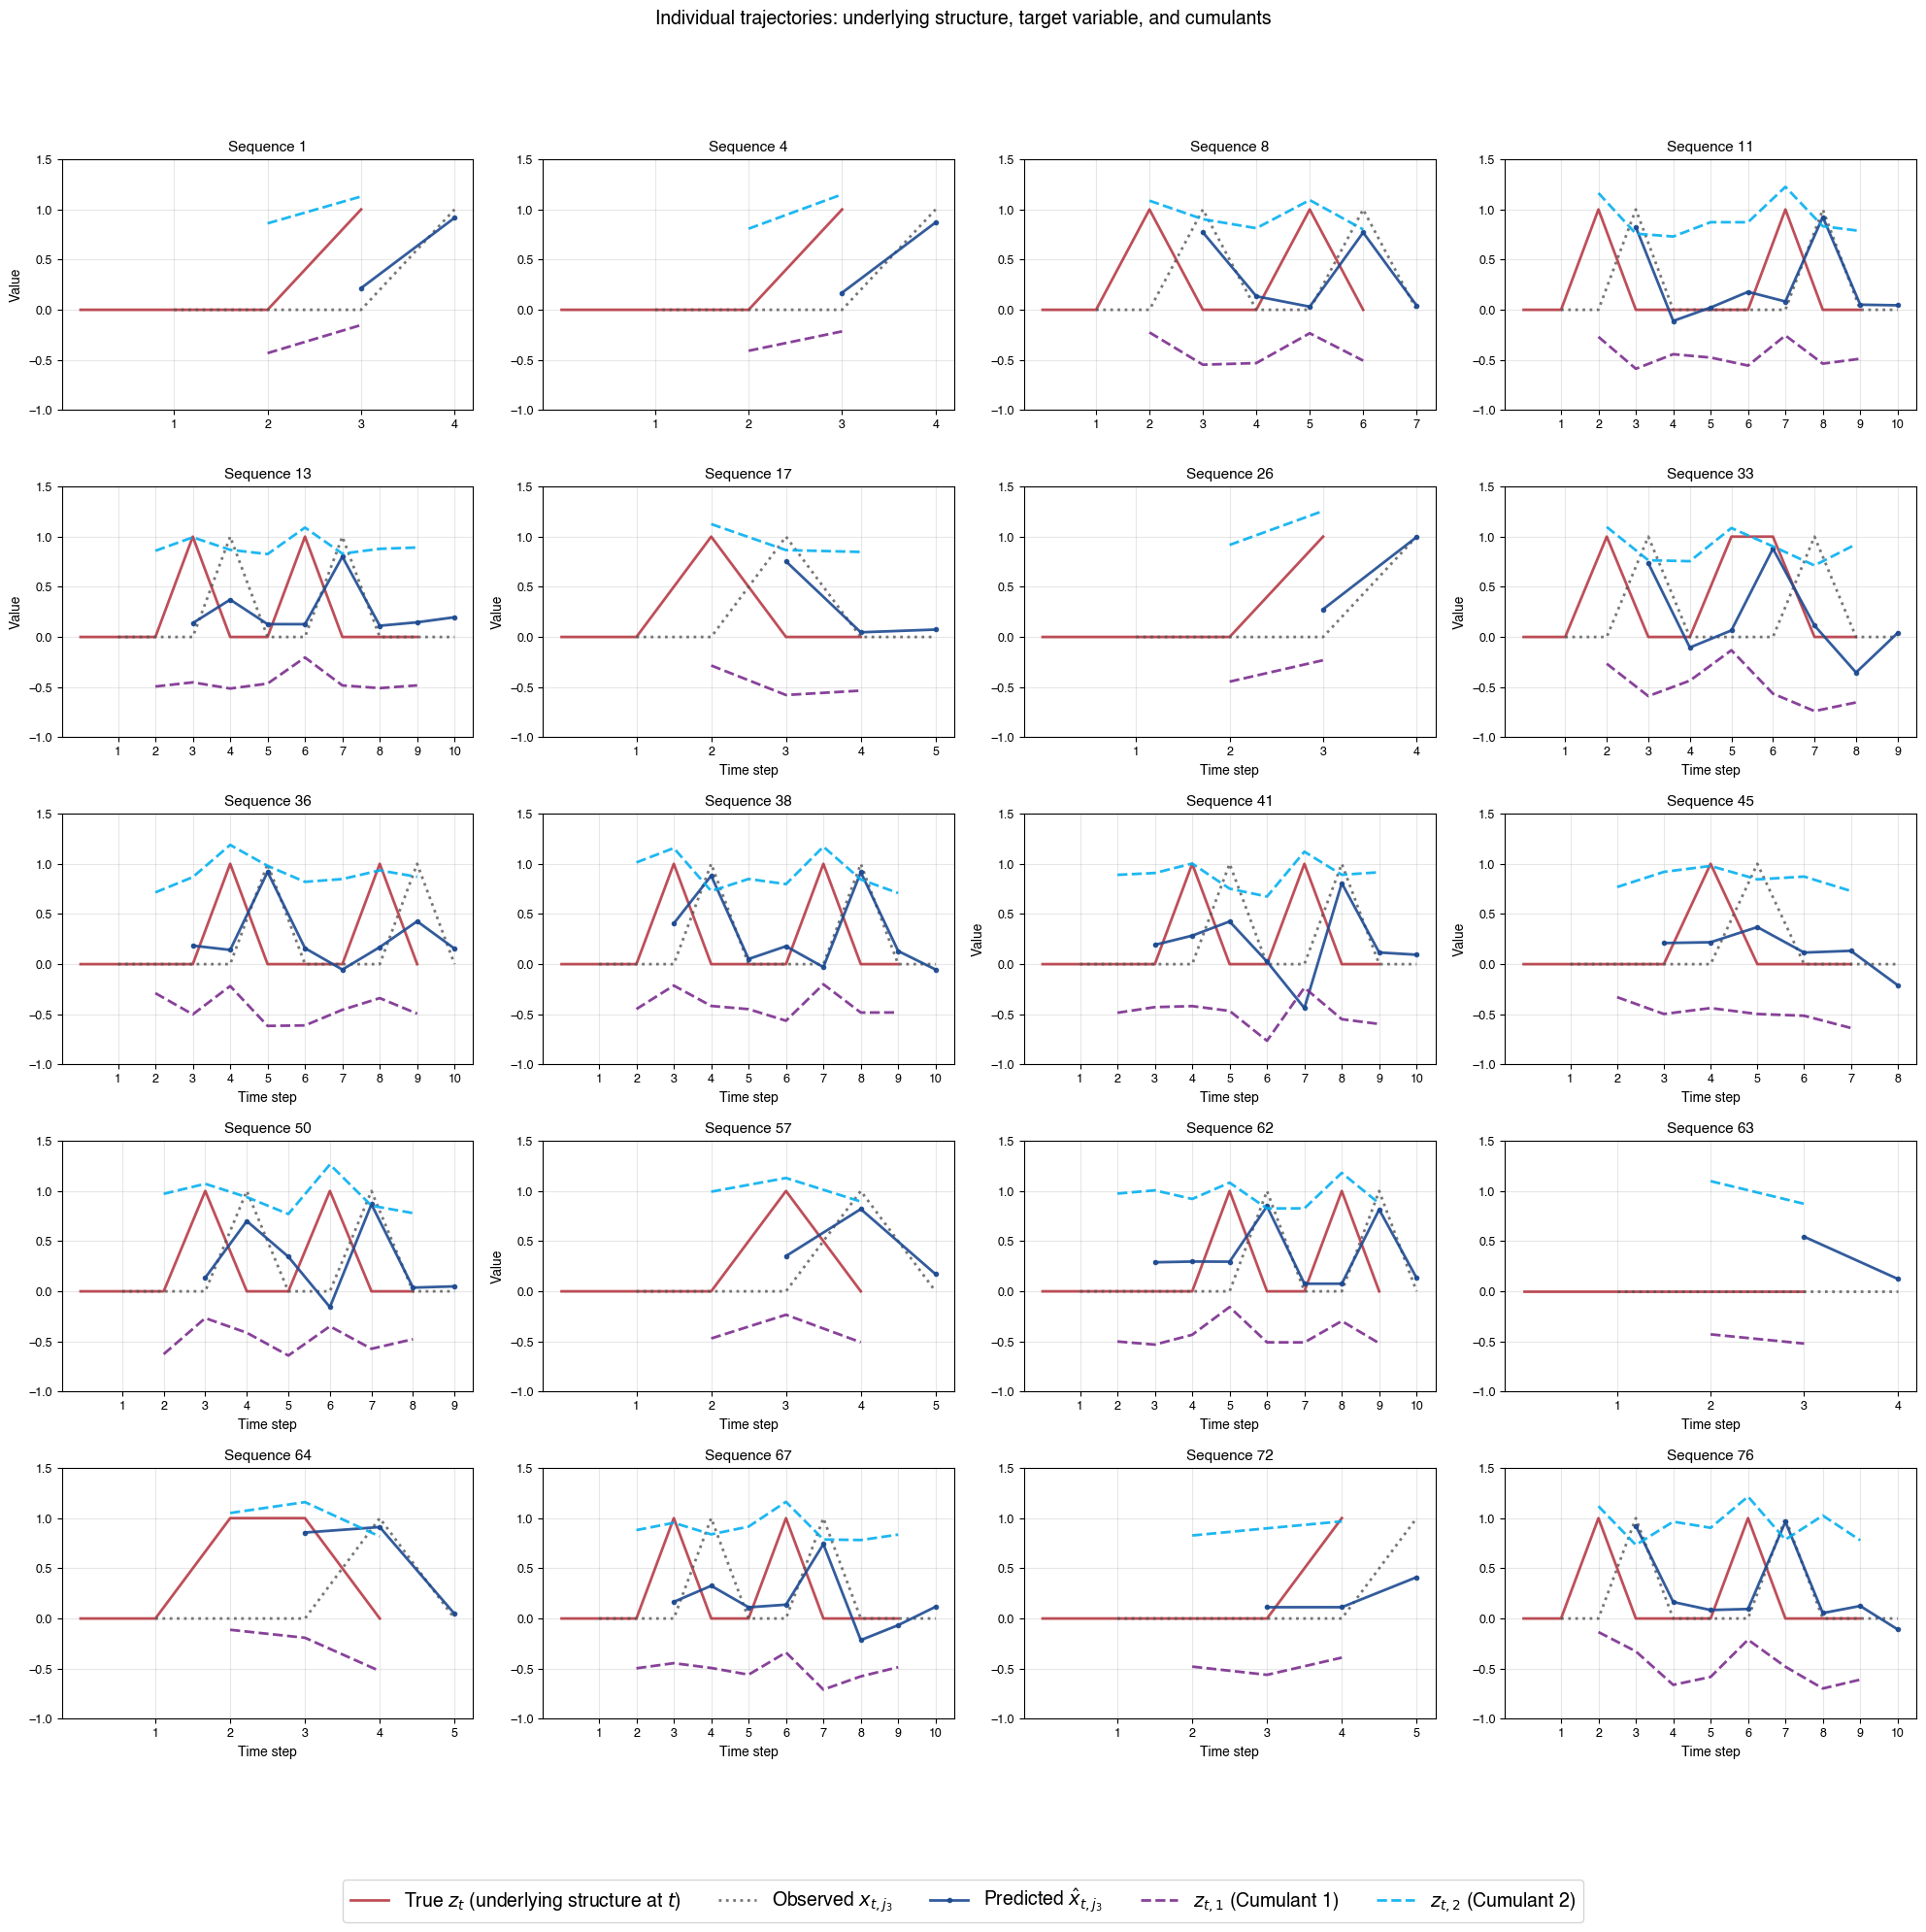

In [101]:
#  set random seed
torch.manual_seed(11)

n_plots = 20


# Paper-consistent colors
COL_RED   = '#AE232F'  # paper red — truth / z_t
COL_BLUE  = '#1D4A91'  # paper blue — model prediction
COL_GRAY  = '#555555'  # observed x_{j3} (secondary reference)
COL_CUM1  = '#7B2D8E'  # purple — cumulant 1
COL_CUM2  = '#05B0F0'  # Vivid Cerulean  — cumulant 2

# Layout: arrange all sequences as subplots in a grid
ncols = 4
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()  # flatten for easy indexing

included_idx = []

plt_idx = 0
for seq_idx, cumulants_np in enumerate(all_cumulants):
    
    
    if torch.rand(1) > 0.3:
        continue
    
    if plt_idx >= n_plots:
        break
    ax = axes[plt_idx]
    
    
    T_cum, ncum_effective = cumulants_np.shape  # T_cum = seq_len - 2
    seq_len = len(all_true_z[seq_idx])
    
    if T_cum == 1:
        continue
    
    included_idx.append(seq_idx)
    
    # z_t at time t (0..T-1); observed x and prediction for next time point (lagged)
    timesteps_true_z = np.array(range(0, seq_len))   # state z_t at t
    timesteps_cum = np.array(range(2, 2 + T_cum))   # cumulants at steps 2..
    timesteps_full = np.array(range(1, seq_len + 1)) # observed x at 1..T
    
    true_z = all_true_z[seq_idx]
    
    # --- True z_t (state at time t) ---
    ax.plot(timesteps_true_z, true_z, linestyle='-', linewidth=2.0,
            color=COL_RED, alpha=0.8, label=r'True $z_{t}$ (underlying structure at $t$)')
    
    # --- Observed x (outcome at each step) ---
    ax.plot(timesteps_full, pred_var[seq_idx],  linestyle=':', linewidth=2.0,
            color=COL_GRAY, alpha=0.8, label=r'Observed $x_{t, j_3}$')
    
    # --- Model prediction for next time point (plotted with lag: timesteps_cum+1) ---
    ax.plot(timesteps_cum+1, all_pred_j3[seq_idx], linestyle='-', linewidth=2.0,
            color=COL_BLUE, alpha=0.9, marker='o', markersize=3, label=r'Predicted $\hat{x}_{t, j_3}$')
    
    # --- Learned cumulants ---
    if ncum_effective >= 1:
        ax.plot(timesteps_cum, cumulants_np[:, 0], linestyle='--', linewidth=2.0,
                color=COL_CUM1, alpha=0.9, label=r'$z_{t, 1}$ (Cumulant 1)')
    if ncum_effective >= 2:
        ax.plot(timesteps_cum, cumulants_np[:, 1], linestyle='--', linewidth=2.0,
                color=COL_CUM2, alpha=0.9, label=r'$z_{t, 2}$ (Cumulant 2)')
    
    ax.set_title(f"Sequence {seq_idx + 1}", fontsize=11)
    ax.set_xticks(timesteps_full)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1, 1.5)
    ax.tick_params(labelsize=9)
    
    # Only show y-label on leftmost subplots
    if seq_idx % ncols == 0:
        ax.set_ylabel("Value", fontsize=10)
    # Only show x-label on bottom row
    if seq_idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Time step", fontsize=10)
        
    plt_idx += 1


# Hide any unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Individual trajectories: underlying structure, target variable, and cumulants", fontsize=14, y=1.01)
fig.tight_layout(rect=[0, 0.10, 1, 0.97])  # leave bottom 10% for legend
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=14,
                 bbox_to_anchor=(0.5, 0.02))

# bbox_extra_artists ensures the legend is included when computing the saved bounding box
fig.savefig("n=500_cumulants_trajectories.pdf", dpi=300, bbox_inches="tight",
            bbox_extra_artists=[leg])
plt.show()
    
    


In [102]:
# Verify mismatch rate: how often does x_{pos3} differ from z when z=1?
mismatch_count = 0
z1_count = 0
z0_count = 0
x1_when_z0 = 0

for i in included_idx: #range(len(all_true_z)):
    for t in range(len(all_true_z[i])):
        if all_true_z[i][t] == 1.0:
            z1_count += 1
            if pred_var[i][t] == 0.0:
                mismatch_count += 1
        else:
            z0_count += 1
            if pred_var[i][t] == 1.0:
                x1_when_z0 += 1

print(f"z=1 steps: {z1_count}")
print(f"  mismatches (z=1, x=0): {mismatch_count}  rate: {mismatch_count/max(z1_count,1):.2%}")
print(f"z=0 steps: {z0_count}")
print(f"  x=1 when z=0:          {x1_when_z0}  rate: {x1_when_z0/max(z0_count,1):.2%}")

z=1 steps: 32
  mismatches (z=1, x=0): 2  rate: 6.25%
z=0 steps: 117
  x=1 when z=0:          0  rate: 0.00%


In [75]:
# save to paper_results folder 
# fig.savefig(f"./notebooks/paper_results/simulation/n={n}_cumulants_trajectories.png", bbox_inches="tight")

fig.savefig(f"./n={n}_cumulants_trajectories.pdf", bbox_inches="tight")